In [2]:
import numpy as np 
import time
import math
import pandas as pd 
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from torch.utils.data import Subset, DataLoader
from torch.optim import Adam
from torchvision.models import resnet18, ResNet18_Weights
from dataclasses import dataclass
from torchvision import datasets
import matplotlib.patches as patches
from torchvision.ops import box_iou
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
import matplotlib.patches as patches
import json

In [3]:
def set_seed(seed = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [5]:
IMAGE_SIZE_A = 32
IMAGE_SIZE_B = 224
BATCH_SIZE = 64

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CNN_MEAN = [0.5, 0.5, 0.5]
CNN_STD = [0.5, 0.5, 0.5]


In [7]:
c1_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_A, IMAGE_SIZE_A)),
    transforms.ToTensor(),
    transforms.Normalize(mean = CNN_MEAN,
                        std= CNN_STD),
])

c2_transform_train = transforms.Compose([
    transforms.RandomCrop(IMAGE_SIZE_A, padding=4),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.Resize((IMAGE_SIZE_A, IMAGE_SIZE_A)),
    transforms.ToTensor(),
    transforms.Normalize(CNN_MEAN,CNN_STD),
])



In [8]:
resnet_transform_train = transforms.Compose([
    transforms.Resize(IMAGE_SIZE_B + 32),
    transforms.RandomResizedCrop(IMAGE_SIZE_B, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

resnet_transform_eval = transforms.Compose([
    transforms.Resize(IMAGE_SIZE_B + 32),
    transforms.CenterCrop(IMAGE_SIZE_B),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [9]:
data_dir = "./data"

In [10]:
def load_ds(train_transform, eval_transform):
    train_ds = torchvision.datasets.STL10(root = data_dir, download = True, split = "train", transform = train_transform)
    train_eval_ds = torchvision.datasets.STL10(root = data_dir, download= True, split = "train", transform = eval_transform)
    test_ds = torchvision.datasets.STL10(root = data_dir, download= True, split = "test", transform = eval_transform)

    return train_ds, train_eval_ds, test_ds

In [11]:
train_ds, train_eval_ds, test_ds = load_ds(c1_transform, c1_transform)
class_names = train_ds.classes

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


In [12]:

def make_loaders(train_ds, train_eval_ds, test_ds, batch_size = 64, val_ratio = 0.2):

    n_total = len(train_ds)
    n_val = int(val_ratio * n_total)

    rng = np.random.RandomState(seed = 42)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]       # Первые 20% -> валидация
    train_idx = indices[n_val:]     # Остальные 80% -> тренировка

    ds_train = Subset(train_ds, train_idx)
    ds_val   = Subset(train_eval_ds, val_idx)

    train_loader = DataLoader(ds_train , batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [13]:
ds_train, ds_val, ds_test = make_loaders(train_ds, train_eval_ds, test_ds)

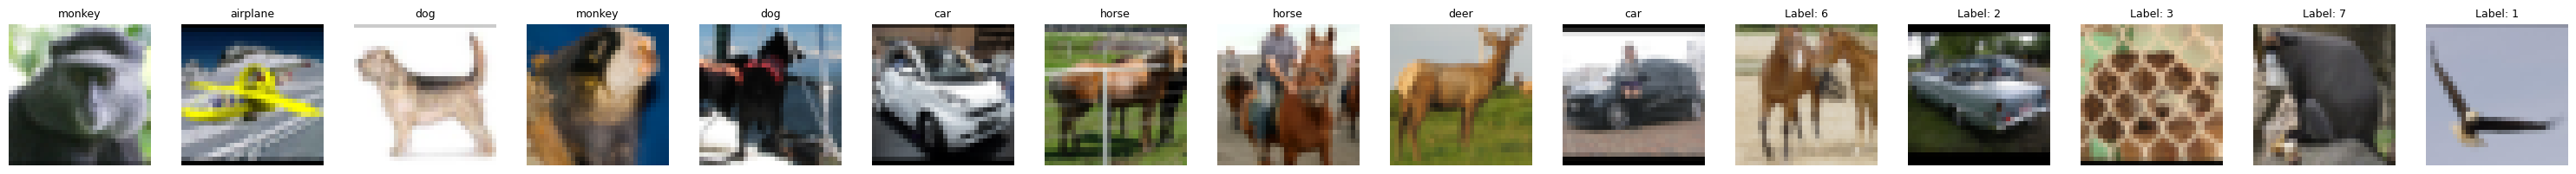

In [14]:
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CNN_MEAN).view(3, 1, 1)
    std = torch.tensor(CNN_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(2 * n, 2))
    
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        
        plt.imshow(img)
        if i < len(class_names):
            plt.title(class_names[y[i].item()], fontsize=9)
        else:
            plt.title(f"Label: {y[i].item()}", fontsize=9)
            
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_images(ds_train, 15)


In [15]:
NUM_CLASSES = 10

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, input_size = 32):
        super().__init__()

        scale = input_size // 8
        flat_features = 128 * scale * scale

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_features, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = SimpleCNN(NUM_CLASSES).to(device)

In [16]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

In [17]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break
    return history


In [18]:
def plot_history(hist, title: str = "") -> None:

    fig, (ax1, ax2)= plt.subplots(1, 2, figsize=(12, 4))
    epochs = list(range(1, len(hist["train_loss"]) + 1))
    plt.title(title)

    ax1.plot(epochs, hist["train_loss"], label="train loss")
    ax1.plot(epochs, hist["val_loss"], label="val loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.set_title(title + " | loss")
    ax1.grid(True)
    ax1.legend()


    ax2.plot(epochs, hist["train_acc"], label="train acc")
    ax2.plot(epochs, hist["val_acc"], label="val acc")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title(title + " | accuracy")
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()  # Автоматически выравнивает отступы
    plt.savefig(f"artifacts/figures/{title}")
    plt.show()

In [19]:
criterion = nn.CrossEntropyLoss()
lr = 1e-3
epochs = 10

Эксперимент C1 (без аугментаций)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Epoch 01/10 | train loss 1.9267, acc 0.275 | val loss 1.7046, acc 0.344 | 4.2s
Epoch 02/10 | train loss 1.5816, acc 0.400 | val loss 1.5206, acc 0.434 | 4.4s
Epoch 03/10 | train loss 1.4492, acc 0.453 | val loss 1.4744, acc 0.444 | 4.2s
Epoch 04/10 | train loss 1.3277, acc 0.501 | val loss 1.4109, acc 0.471 | 4.3s
Epoch 05/10 | train loss 1.2379, acc 0.537 | val loss 1.3112, acc 0.519 | 4.2s
Epoch 06/10 | train loss 1.1179, acc 0.585 | val loss 1.3663, acc 0.505 | 4.2s
Epoch 07/10 | train loss 1.0210, acc 0.626 | val loss 1.3519, acc 0.515 | 5.3s
Epoch 08/10 | train loss 0.9167, acc 0.661 | val loss 1.3393, acc 0.519 | 6.0s
Epoch 09/10 | train loss 0.8126, acc 0.699 | val loss 1.2925, acc 0.539 | 4.7s
Epoch 10/10 | train loss 0.7079, acc 0.749 | val loss 1.4478, acc 0.544 | 4.8s


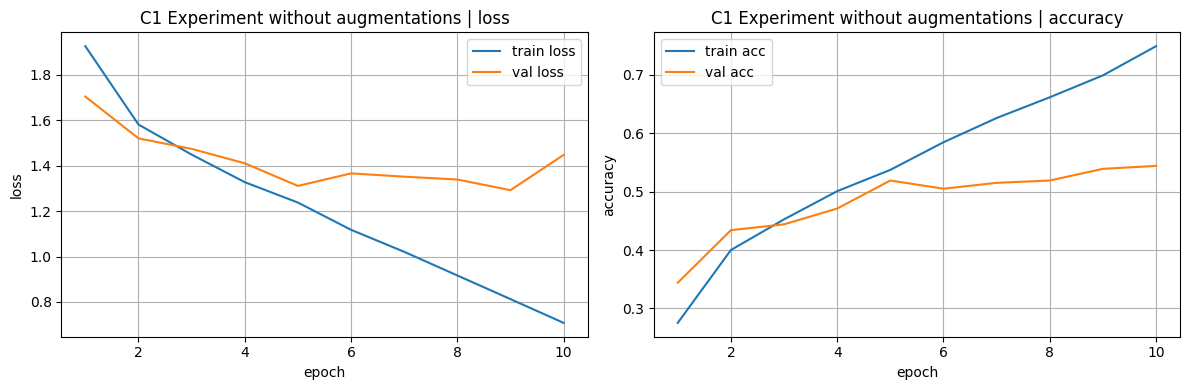


C1 Test Results: Loss = 1.4478, Accuracy = 0.544


In [20]:
# C Experiment: Simple CNN without augmentations
temp_train_ds_c1, temp_val_ds_c1, temp_test_ds_c1 = load_ds(c1_transform, c1_transform)

train_loader_c1, val_loader_c1, test_loader_c1 = make_loaders(temp_train_ds_c1, temp_val_ds_c1, temp_test_ds_c1)

model_c1 = SimpleCNN(NUM_CLASSES, input_size = 32).to(device)
optimizer_c1 = Adam(model_c1.parameters(), lr = lr)

hist_c1 = fit(model_c1, train_loader_c1, val_loader_c1, optimizer_c1, criterion, epochs=epochs)
plot_history(hist_c1, title="C1 Experiment without augmentations")
# Evaluate on test set
test_loss_c1, val_acc_c1 = evaluate(model_c1, val_loader_c1, criterion)
print(f"\nC1 Test Results: Loss = {test_loss_c1:.4f}, Accuracy = {val_acc_c1:.3f}")

Эксперимент C2 (с аугментациями)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Epoch 01/10 | train loss 2.1836, acc 0.165 | val loss 1.9919, acc 0.247 | 4.3s
Epoch 02/10 | train loss 2.0277, acc 0.222 | val loss 1.8350, acc 0.266 | 4.9s
Epoch 03/10 | train loss 1.9628, acc 0.234 | val loss 1.8415, acc 0.245 | 5.0s
Epoch 04/10 | train loss 1.9162, acc 0.256 | val loss 1.8059, acc 0.310 | 6.3s
Epoch 05/10 | train loss 1.8881, acc 0.263 | val loss 1.7346, acc 0.318 | 6.1s
Epoch 06/10 | train loss 1.8624, acc 0.280 | val loss 1.6803, acc 0.360 | 4.9s
Epoch 07/10 | train loss 1.8572, acc 0.282 | val loss 1.7242, acc 0.325 | 4.8s
Epoch 08/10 | train loss 1.8181, acc 0.300 | val loss 1.7480, acc 0.319 | 5.0s
Epoch 09/10 | train loss 1.8022, acc 0.297 | val loss 1.6959, acc 0.327 | 4.7s
Epoch 10/10 | train loss 1.7979, acc 0.304 | val loss 1.6254, acc 0.385 | 5.4s


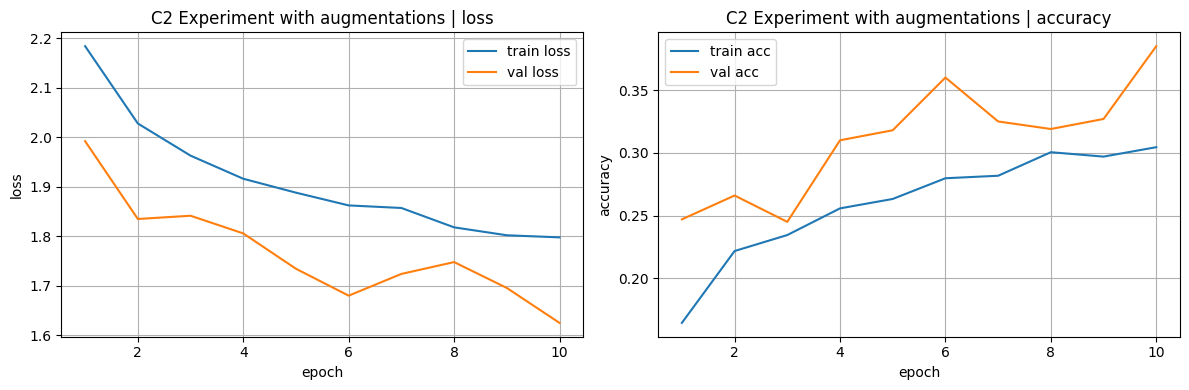


C2 Test Results: Loss = 1.6254, Accuracy = 0.385


In [21]:
temp_train_ds_c2, temp_val_ds_c2, temp_test_ds_c2 = load_ds(c2_transform_train, c1_transform)

train_loader_c2, val_loader_c2, test_loader_c2 = make_loaders(temp_train_ds_c2, temp_val_ds_c2, temp_test_ds_c2)

model_c2 = SimpleCNN(NUM_CLASSES, input_size=32).to(device)
optimizer_c2 = Adam(model_c2.parameters(), lr= lr)

hist_c2 = fit(model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion, epochs=epochs)
plot_history(hist_c2, title="C2 Experiment with augmentations")

test_loss_c2, val_acc_c2 = evaluate(model_c2, val_loader_c2, criterion)
print(f"\nC2 Test Results: Loss = {test_loss_c2:.4f}, Accuracy = {val_acc_c2:.3f}")

Эксперимент C3 (ResNet18 с pretrained weights)

In [22]:
def get_resnet18_weights():
    w = ResNet18_Weights.DEFAULT
    return w

weights = get_resnet18_weights()
print("weights: ", weights)

weights:  ResNet18_Weights.IMAGENET1K_V1


In [23]:
def count_trainable_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes = 10, weights = weights):
    model = resnet18(weights=weights)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag):
    for p in module.parameters():
        p.requires_grad = flag

module = build_resnet18(10, weights = weights).to(device)

In [24]:
temp_train_ds_c3, temp_val_ds_c3, temp_test_ds_c3 = load_ds(resnet_transform_train, resnet_transform_eval)

train_loader_c3, val_loader_c3, test_loader_c3 = make_loaders(temp_train_ds_c3, temp_val_ds_c3, temp_test_ds_c3)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


Trainable parameters in head: 5,130
Epoch 01/3 | train loss 1.0204, acc 0.751 | val loss 0.4560, acc 0.912 | 81.5s
Epoch 02/3 | train loss 0.3648, acc 0.922 | val loss 0.3152, acc 0.915 | 106.2s
Epoch 03/3 | train loss 0.2691, acc 0.934 | val loss 0.2566, acc 0.925 | 98.1s


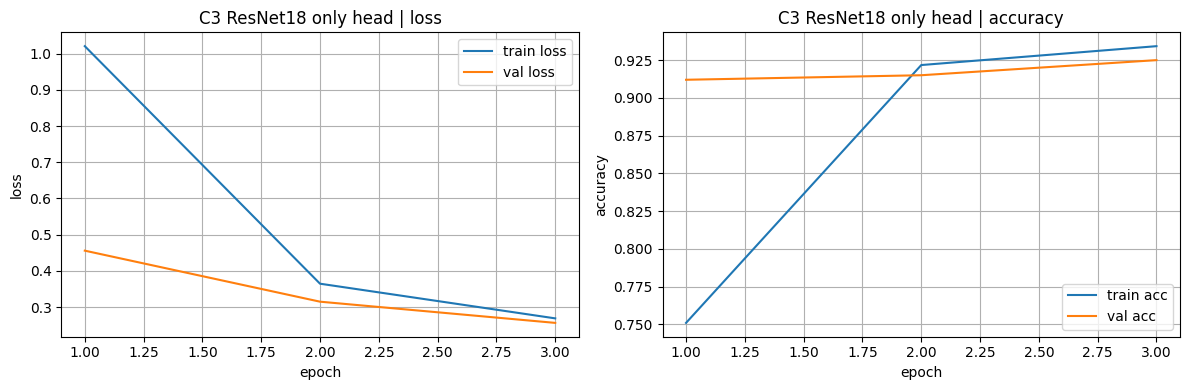


C3 Test Results: Loss = 0.2566, Accuracy = 0.925


In [25]:
EPOCHS_HEAD = 3

model_head = build_resnet18(10, weights=weights).to(device)

set_requires_grad(model_head, False)

set_requires_grad(model_head.fc, True)

# Проверяем, сколько параметров будет обучаться
trainable_params = count_trainable_params(model_head)
print(f"Trainable parameters in head: {trainable_params:,}")

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

hist_head = fit(model_head, train_loader_c3, val_loader_c3, optimizer_head, criterion, epochs=EPOCHS_HEAD)
plot_history(hist_head, title="C3 ResNet18 only head")

test_loss_c3, val_acc_c3 = evaluate(model_head, val_loader_c3, criterion)
print(f"\nC3 Test Results: Loss = {test_loss_c3:.4f}, Accuracy = {val_acc_c3:.3f}")

Эксперимент C4

Trainable params (layer4 + fc): 8,398,858
Epoch 01/3 | train loss 0.5070, acc 0.852 | val loss 0.1782, acc 0.942 | 112.5s
Epoch 02/3 | train loss 0.1097, acc 0.969 | val loss 0.1670, acc 0.946 | 100.1s
Epoch 03/3 | train loss 0.0577, acc 0.987 | val loss 0.1634, acc 0.946 | 89.9s


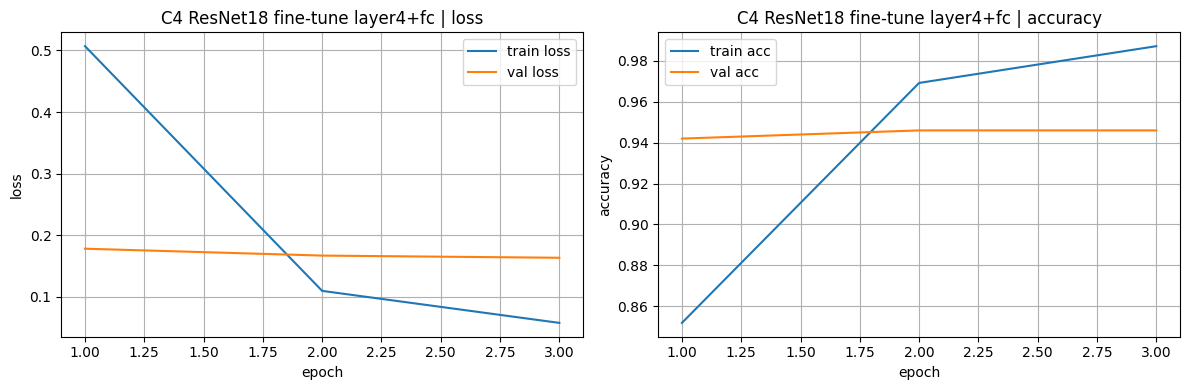


C4 Test Results: Loss = 0.1634, Accuracy = 0.946


In [26]:
EPOCHS_FT = 3

# Создаем новую модель для C4 (не переиспользуем C3)
model_ft = build_resnet18(10, weights=weights).to(device)

# Замораживаем весь backbone
set_requires_grad(model_ft, False)

# Размораживаем ТОЛЬКО layer4 и fc
set_requires_grad(model_ft.layer4, True)
set_requires_grad(model_ft.fc, True)

trainable_params = count_trainable_params(model_ft)
print(f"Trainable params (layer4 + fc): {trainable_params:,}")

params = [
    {"params": model_ft.layer4.parameters(), "lr": 1e-4},
    {"params": model_ft.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

hist_ft = fit(model_ft, train_loader_c3, val_loader_c3, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="C4 ResNet18 fine-tune layer4+fc")

test_loss_c4, val_acc_c4 = evaluate(model_ft, val_loader_c3, criterion)
print(f"\nC4 Test Results: Loss = {test_loss_c4:.4f}, Accuracy = {val_acc_c4:.3f}")

По val_accuracy лучшая модель была в эксперементе C4, с показателем 0.941

Сохранение параметров лучшего графика

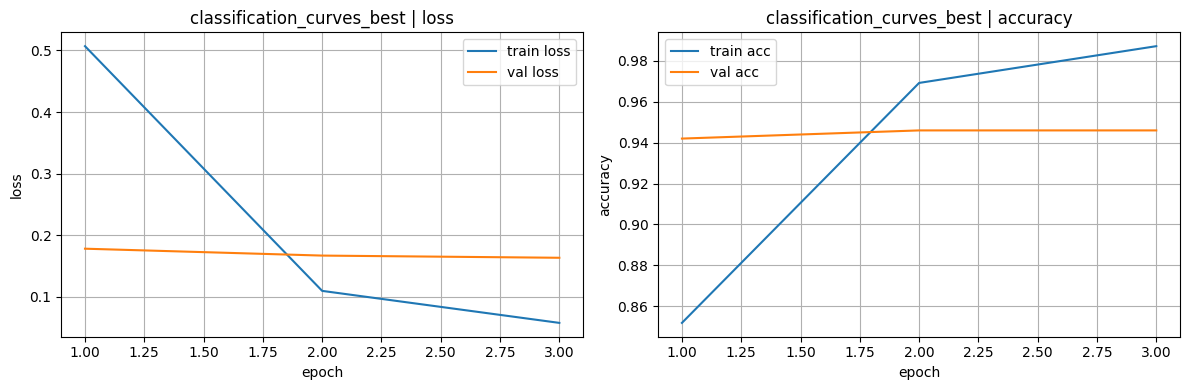

Best results accuracy: 0.9437


In [27]:
test_loss, test_acc = evaluate(model_ft, test_loader_c3, criterion)
plot_history(hist_ft, "classification_curves_best")
print(f"Best results accuracy: {test_acc:.4}")

Сохранение результата лучшей модели

In [28]:
torch.save(model_ft.state_dict(), "artifacts/best_classifier.pt")

Сохранение конфига лучшей модели

In [30]:
best_conf = {
    "experinent_id": "C4_resnet18_layer4_fc_finetune",
    "layer": "layer4+fc",
    "task": "classification",
    "trainable_params": trainable_params,
    "lr": {
        "layer4": 1e-4,
        "fc": 1e-3 
        },
    "optimizer": "Adam",
    "criterion": "CrossEntropyLoss",
    "epochs": EPOCHS_FT,
    "verbose": True,
    "seed": 42,
    "model_summary": str(model_ft)
}

with open("artifacts/best_classifier_config.json", "w", encoding = "utf-8") as f:
    json.dump(best_conf, f, indent = 4)

Сравнение val_accuracy всех моделей

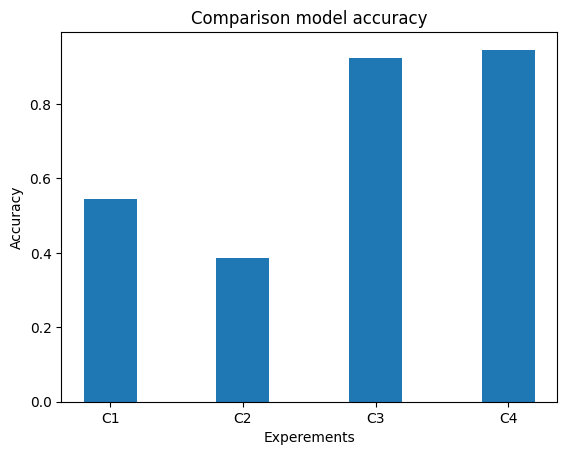

In [31]:
def plt_bar(X = ["C1", "C2", "C3", "C4"], y = [val_acc_c1, val_acc_c2, val_acc_c3, val_acc_c4]):
    plt.bar(X, y, width=0.4)
    plt.title("Comparison model accuracy")
    plt.xlabel("Experements")
    plt.ylabel("Accuracy")
    plt.savefig("artifacts/figures/classification_compare")
    plt.show()

plt_bar()

Files already downloaded and verified


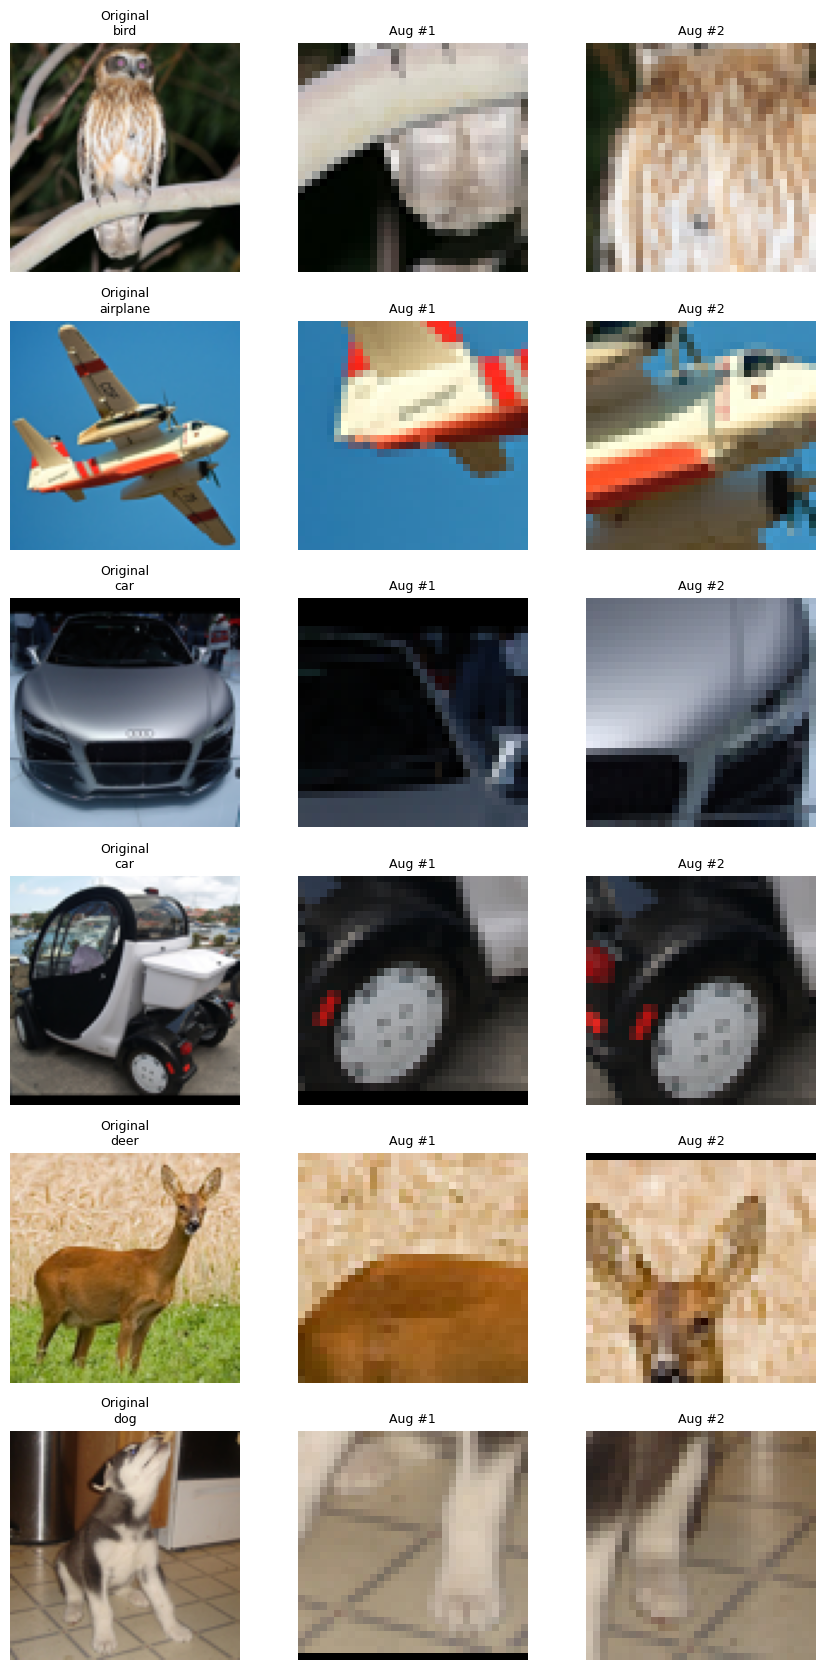

Saved: artifacts/figures/augmentations_preview.png


In [ ]:
from pathlib import Path
from torchvision.transforms.functional import to_pil_image


def visualize_augmentations(dataset, transform, n_samples=6, repeats=2, save_path="figures/augmentations_preview.png", seed=42):
    """
    Visualize augmentations for Part A.
    Left column is original image, next columns are repeated transformed variants.
    """
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(len(indices), repeats + 1, figsize=(3 * (repeats + 1), 2.8 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        img, label = dataset[int(idx)]

        if isinstance(img, torch.Tensor):
            img_pil = to_pil_image(img.cpu())
        else:
            img_pil = img

        axes[row, 0].imshow(np.asarray(img_pil))
        title = class_names[label] if isinstance(label, (int, np.integer)) and label < len(class_names) else f"label={label}"
        axes[row, 0].set_title(f"Original\n{title}", fontsize=9)
        axes[row, 0].axis("off")

        for col in range(1, repeats + 1):
            aug_tensor = transform(img_pil)
            aug_img = denorm_stl(aug_tensor).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
            axes[row, col].imshow(aug_img)
            axes[row, col].set_title(f"Aug #{col}", fontsize=9)
            axes[row, col].axis("off")

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


raw_train_ds = torchvision.datasets.STL10(root=data_dir, download=True, split="train", transform=None)
visualize_augmentations(
    dataset=raw_train_ds,
    transform=c2_transform_train,
    n_samples=6,
    repeats=2,
    save_path="artifacts/figures/augmentations_preview.png",
)

S11

In [33]:
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

@dataclass
class RunConfig:
    data_root: str = "./data_voc"
    artifacts_dir: str = "./artifacts"
    n_show: int = 5
    thresholds: Tuple[float, float] = (0.3, 0.7)
    iou_thr: float = 0.5
    random_seed: int = 42

cfg = RunConfig()
np.random.seed(cfg.random_seed)
Path(cfg.artifacts_dir).mkdir(parents=True, exist_ok=True)

In [34]:
data_root = cfg.data_root

# Для torchvision detection-моделей подаём изображение как Tensor в диапазоне [0, 1].
# Внутренняя transform модели сама делает нужную нормализацию.
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_voc_ds = datasets.VOCDetection(
    root=data_root,
    download=True,
    image_set="train",
    transform=transform,
    target_transform=None,
 )

val_voc_ds = datasets.VOCDetection(
    root=data_root,
    download=True,
    image_set="val",
    transform=transform,
    target_transform=None,
 )

Using downloaded and verified file: ./data_voc\VOCtrainval_11-May-2012.tar
Extracting ./data_voc\VOCtrainval_11-May-2012.tar to ./data_voc
Using downloaded and verified file: ./data_voc\VOCtrainval_11-May-2012.tar
Extracting ./data_voc\VOCtrainval_11-May-2012.tar to ./data_voc


In [35]:
VOC_CLASSES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

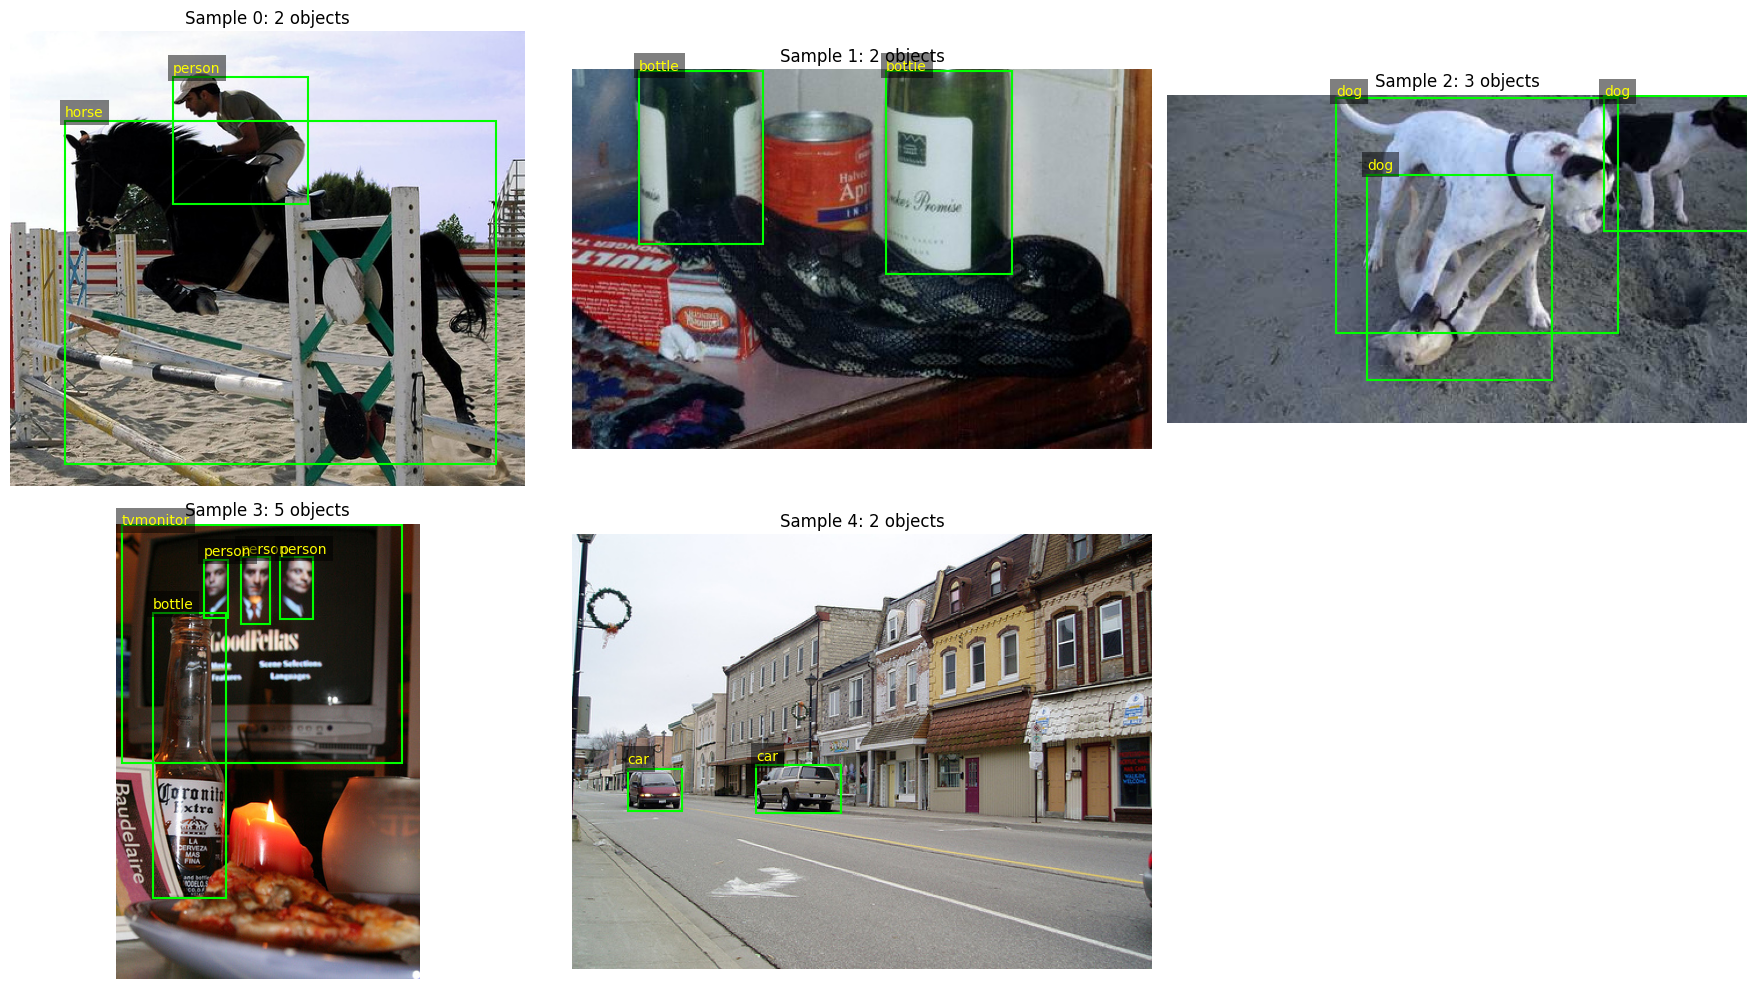

In [36]:
def sanity_check_voc(dataset, n=6):
    n = min(n, len(dataset))
    cols = min(3, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        image, annotation = dataset[i]
        img_np = image.permute(1, 2, 0).numpy()

        axes[i].imshow(img_np)
        axes[i].axis("off")

        raw_objects = annotation["annotation"]["object"]
        objects_list = raw_objects if isinstance(raw_objects, list) else [raw_objects]

        for obj in objects_list:
            bbox = obj["bndbox"]
            xmin = int(bbox["xmin"]); ymin = int(bbox["ymin"])
            xmax = int(bbox["xmax"]); ymax = int(bbox["ymax"])
            w = xmax - xmin; h = ymax - ymin

            rect = patches.Rectangle((xmin, ymin), w, h, linewidth=1.5, edgecolor="lime", facecolor="none")
            axes[i].add_patch(rect)
            axes[i].text(
                xmin,
                max(ymin - 5, 0),
                obj["name"],
                color="yellow",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
            )

        axes[i].set_title(f"Sample {i}: {len(objects_list)} objects")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

sanity_check_voc(train_voc_ds, n=cfg.n_show)

In [37]:
def detection_collate_fn(batch):
    """
    Собирает батч из списка картинок разного размера.
    Возвращает: (list[images], list[targets])
    """
    images = []
    targets = []
    for img, target in batch:
        images.append(img)
        targets.append(target)
    return images, targets

batch_size = 4

train_loader = DataLoader(train_voc_ds , batch_size=batch_size, shuffle=True, collate_fn=detection_collate_fn)
val_loader = DataLoader(val_voc_ds, batch_size=4, shuffle=False, collate_fn=detection_collate_fn)   

In [38]:
weights = FasterRCNN_ResNet50_FPN_Weights.COCO_V1
model = fasterrcnn_resnet50_fpn(weights=weights)

# Переключаем в режим оценки (eval) - важно для детекции!
model.eval()

# Переносим на устройство (CUDA или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [39]:
def box_iou_matrix(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), device=boxes1.device)
    
    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)
    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union


In [40]:
def parse_voc_gt(annotation):
    objs = annotation['annotation']['object']
    if not isinstance(objs, list): objs = [objs]
    
    boxes = []
    labels = []
    
    for obj in objs:
        b = obj['bndbox']
        boxes.append([float(b['xmin']), float(b['ymin']), float(b['xmax']), float(b['ymax'])])
        labels.append(obj['name'])
        
    if len(boxes) == 0:
        return torch.zeros((0, 4), device=device), []
    return torch.tensor(boxes, dtype=torch.float32, device=device), labels


In [41]:
COCO_CLASSES = weights.meta['categories']

In [42]:
def calculate_metrics(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    """
    Greedy matching: predictions are sorted by score and each GT can be matched once.
    Returns TP, FP, FN, list of matched IoUs, mean IoU, precision, recall.
    """
    if pred_boxes.numel() == 0 and gt_boxes.numel() == 0:
        return 0, 0, 0, [], 0.0, 0.0, 0.0
    if pred_boxes.numel() == 0:
        fn = int(gt_boxes.shape[0])
        return 0, 0, fn, [], 0.0, 0.0, 0.0
    if gt_boxes.numel() == 0:
        fp = int(pred_boxes.shape[0])
        return 0, fp, 0, [], 0.0, 0.0, 0.0

    _, indices = torch.sort(pred_scores, descending=True)
    pred_boxes_sorted = pred_boxes[indices]

    ious = box_iou_matrix(pred_boxes_sorted, gt_boxes)
    gt_matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool, device=gt_boxes.device)

    tp, fp = 0, 0
    matched_ious = []

    for p_idx in range(pred_boxes_sorted.shape[0]):
        best_iou_val, best_g_idx = torch.max(ious[p_idx], dim=0)
        best_iou_val = float(best_iou_val.item())
        best_g_idx = int(best_g_idx.item())

        if best_iou_val >= iou_thr and not gt_matched[best_g_idx]:
            tp += 1
            gt_matched[best_g_idx] = True
            matched_ious.append(best_iou_val)
        else:
            fp += 1

    fn = int((~gt_matched).sum().item())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    return tp, fp, fn, matched_ious, mean_iou, precision, recall

In [43]:
def visualize_detection(img_tensor, pred_boxes, pred_scores, pred_labels, title):
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    plt.figure(figsize=(15, 10))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold')
    
    for i in range(len(pred_boxes)):
        x1, y1, x2, y2 = pred_boxes[i]
        score = pred_scores[i]
        label = pred_labels[i]
        
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='yellow', facecolor='none')
        plt.gca().add_patch(rect)
        plt.text(x1, y1-5, f"{label}: {score:.2f}", color='yellow', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.6))
    plt.tight_layout()
    plt.show()


In [44]:
n_samples = min(cfg.n_show, len(val_voc_ds))
dataset = val_voc_ds

sample_indices = np.random.choice(len(dataset), n_samples, replace=False)
images_list = []
gts_list = []

for idx in sample_indices:
    img, ann = dataset[int(idx)]
    gt_boxes, _ = parse_voc_gt(ann)
    images_list.append(img)
    gts_list.append(gt_boxes)

print(f"Prepared {n_samples} validation samples for visualization and metrics.")

Prepared 5 validation samples for visualization and metrics.


In [45]:
thresholds = list(cfg.thresholds)
results_summary = []


--- Inference mode: score_threshold = 0.3 ---


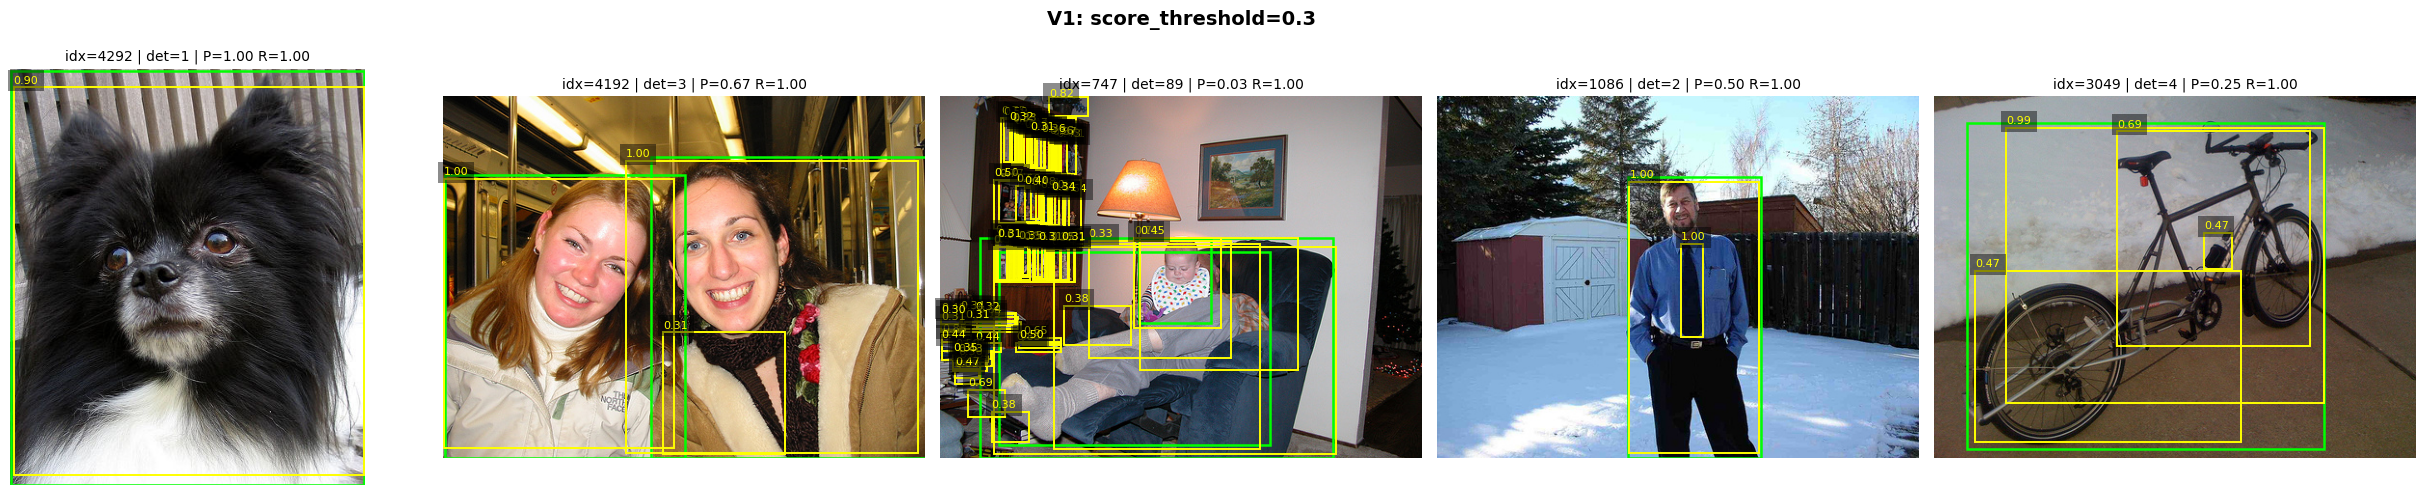

Aggregate metrics for V1 (thr=0.3):
  TP=8, FP=91, FN=0
  Precision: 0.081
  Recall:    1.000
  Mean IoU:  0.847

--- Inference mode: score_threshold = 0.7 ---


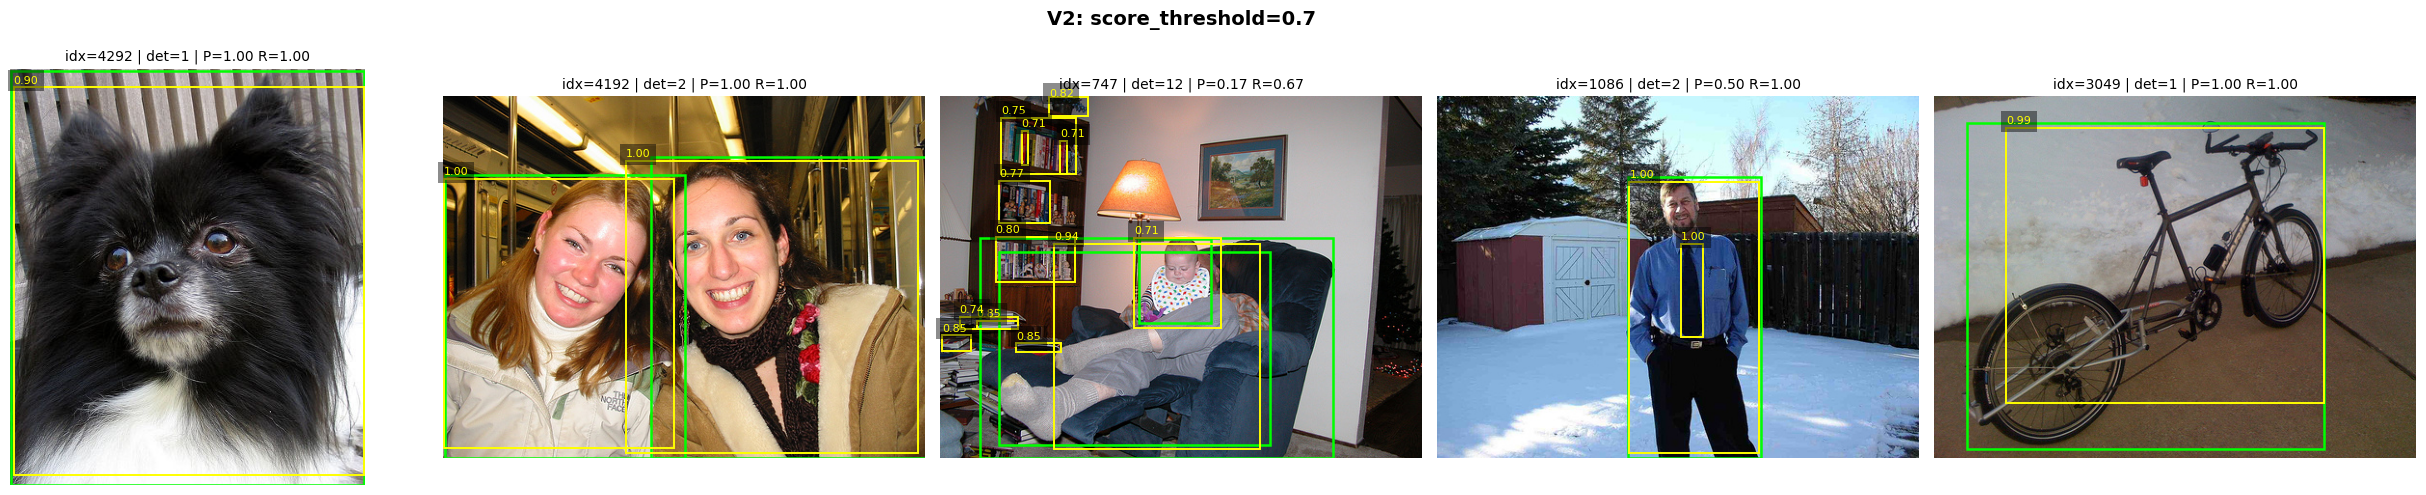

Aggregate metrics for V2 (thr=0.7):
  TP=7, FP=11, FN=1
  Precision: 0.389
  Recall:    0.875
  Mean IoU:  0.840

Saved summary table: ./artifacts\runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN (input 32),Adam,0.001,10,0.544,0.54400,NaN,NaN,NaN,No augmentations; metric was printed as Test R...
1,C2,classification,STL10,42,SimpleCNN (input 32) + augmentations,Adam,0.001,10,0.385,0.38500,NaN,NaN,NaN,RandomCrop + RandomHorizontalFlip
2,C3,classification,STL10,42,ResNet18 pretrained (head only),Adam,0.001,3,0.925,0.92500,NaN,NaN,NaN,Frozen backbone; train fc only
3,C4,classification,STL10,42,ResNet18 pretrained (fine-tune layer4+fc),Adam,layer4:0.0001;fc:0.001,3,0.946,0.94375,NaN,NaN,NaN,Best val model in notebook; test_accuracy from...
4,V1,detection,VOC2012 val,42,FasterRCNN ResNet50 FPN (COCO_V1),N/A,N/A,N/A,NaN,NaN,0.080808,1.000,0.847250,score_threshold=0.3; iou_threshold=0.5; sample...
5,V2,detection,VOC2012 val,42,FasterRCNN ResNet50 FPN (COCO_V1),N/A,N/A,N/A,NaN,NaN,0.388889,0.875,0.839839,score_threshold=0.7; iou_threshold=0.5; sample...
6,V1,detection,VOC2012 val,42,FasterRCNN ResNet50 FPN (COCO_V1),N/A,N/A,N/A,NaN,NaN,0.080808,1.000,0.847250,score_threshold=0.3; iou_threshold=0.5; sample...
7,V2,detection,VOC2012 val,42,FasterRCNN ResNet50 FPN (COCO_V1),N/A,N/A,N/A,NaN,NaN,0.388889,0.875,0.839839,score_threshold=0.7; iou_threshold=0.5; sample...


In [49]:
for thr in thresholds:
    print(f"\n--- Inference mode: score_threshold = {thr} ---")

    total_tp, total_fp, total_fn = 0, 0, 0
    all_matched_ious = []

    fig, axes = plt.subplots(1, n_samples, figsize=(5 * n_samples, 5))
    if n_samples == 1:
        axes = [axes]

    for i, idx in enumerate(sample_indices):
        img = images_list[i].to(device)
        gt_boxes = gts_list[i]

        with torch.no_grad():
            preds = model([img])[0]

        # Filter predictions by score threshold
        mask = preds["scores"] >= thr
        p_boxes = preds["boxes"][mask]
        p_scores = preds["scores"][mask]
        p_labels_idx = preds["labels"][mask]

        # Optional class names for debugging/inspection
        _ = [COCO_CLASSES[int(l)] if int(l) < len(COCO_CLASSES) else f"ID_{int(l)}" for l in p_labels_idx.cpu().numpy()]

        tp, fp, fn, matched_ious, _, prec, rec = calculate_metrics(
            p_boxes, p_scores, gt_boxes, iou_thr=cfg.iou_thr
        )

        total_tp += tp
        total_fp += fp
        total_fn += fn
        all_matched_ious.extend(matched_ious)

        ax = axes[i]
        ax.imshow(img.cpu().permute(1, 2, 0).numpy())
        ax.axis("off")
        ax.set_title(f"idx={int(idx)} | det={len(p_boxes)} | P={prec:.2f} R={rec:.2f}", fontsize=10)

        # Ground truth boxes (green)
        for j in range(len(gt_boxes)):
            x1, y1, x2, y2 = gt_boxes[j].detach().cpu().numpy()
            rect_gt = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.8, edgecolor="lime", facecolor="none")
            ax.add_patch(rect_gt)

        # Predicted boxes (yellow)
        for j in range(len(p_boxes)):
            x1, y1, x2, y2 = p_boxes[j].detach().cpu().numpy()
            rect_pred = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.4, edgecolor="yellow", facecolor="none")
            ax.add_patch(rect_pred)
            ax.text(
                x1,
                max(y1 - 4, 0),
                f"{float(p_scores[j]):.2f}",
                color="yellow",
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.45, edgecolor="none"),
            )

    mode_name = "V1" if np.isclose(thr, 0.3) else "V2"
    plt.suptitle(f"{mode_name}: score_threshold={thr}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("artifacts/figures/detection_examples.png")
    plt.show()

    agg_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    agg_rec = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    agg_miou = float(np.mean(all_matched_ious)) if all_matched_ious else 0.0

    results_summary.append(
        {
            "mode": mode_name,
            "score_threshold": float(thr),
            "iou_threshold": float(cfg.iou_thr),
            "samples": int(n_samples),
            "tp": int(total_tp),
            "fp": int(total_fp),
            "fn": int(total_fn),
            "precision": float(agg_prec),
            "recall": float(agg_rec),
            "mean_iou": float(agg_miou),
        }
    )

    print(f"Aggregate metrics for {mode_name} (thr={thr}):")
    print(f"  TP={total_tp}, FP={total_fp}, FN={total_fn}")
    print(f"  Precision: {agg_prec:.3f}")
    print(f"  Recall:    {agg_rec:.3f}")
    print(f"  Mean IoU:  {agg_miou:.3f}")


def safe_float(value):
    try:
        return float(value)
    except Exception:
        return np.nan


unified_columns = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

classification_rows = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "SimpleCNN (input 32)",
        "optimizer": "Adam",
        "lr": "0.001",
        "epochs_trained": 10,
        "best_val_accuracy": safe_float(globals().get("val_acc_c1")),
        "test_accuracy": safe_float(globals().get("val_acc_c1")),
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "No augmentations; metric was printed as Test Results but evaluated on val_loader",
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "SimpleCNN (input 32) + augmentations",
        "optimizer": "Adam",
        "lr": "0.001",
        "epochs_trained": 10,
        "best_val_accuracy": safe_float(globals().get("val_acc_c2")),
        "test_accuracy": safe_float(globals().get("val_acc_c2")),
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "RandomCrop + RandomHorizontalFlip",
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "ResNet18 pretrained (head only)",
        "optimizer": "Adam",
        "lr": "0.001",
        "epochs_trained": 3,
        "best_val_accuracy": safe_float(globals().get("val_acc_c3")),
        "test_accuracy": safe_float(globals().get("val_acc_c3")),
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "Frozen backbone; train fc only",
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "ResNet18 pretrained (fine-tune layer4+fc)",
        "optimizer": "Adam",
        "lr": "layer4:0.0001;fc:0.001",
        "epochs_trained": 3,
        "best_val_accuracy": safe_float(globals().get("val_acc_c4")),
        "test_accuracy": safe_float(globals().get("test_acc")),
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": "Best val model in notebook; test_accuracy from separate test_loader evaluation",
    },
]

detection_rows = []
for row in results_summary:
    detection_rows.append(
        {
            "experiment_id": str(row["mode"]),
            "task": "detection",
            "dataset": "VOC2012 val",
            "seed": int(cfg.random_seed),
            "model_summary": "FasterRCNN ResNet50 FPN (COCO_V1)",
            "optimizer": "N/A",
            "lr": "N/A",
            "epochs_trained": "N/A",
            "best_val_accuracy": np.nan,
            "test_accuracy": np.nan,
            "precision": float(row["precision"]),
            "recall": float(row["recall"]),
            "mean_iou": float(row["mean_iou"]),
            "notes": (
                f"score_threshold={row['score_threshold']}; "
                f"iou_threshold={row['iou_threshold']}; "
                f"samples={row['samples']}; TP={row['tp']} FP={row['fp']} FN={row['fn']}"
            ),
        }
    )

runs_df = pd.DataFrame(classification_rows + detection_rows, columns=unified_columns)
runs_path = os.path.join(cfg.artifacts_dir, "runs.csv")
runs_df.to_csv(runs_path, index=False)

print("\nSaved summary table:", runs_path)
runs_df

<Figure size 800x480 with 0 Axes>

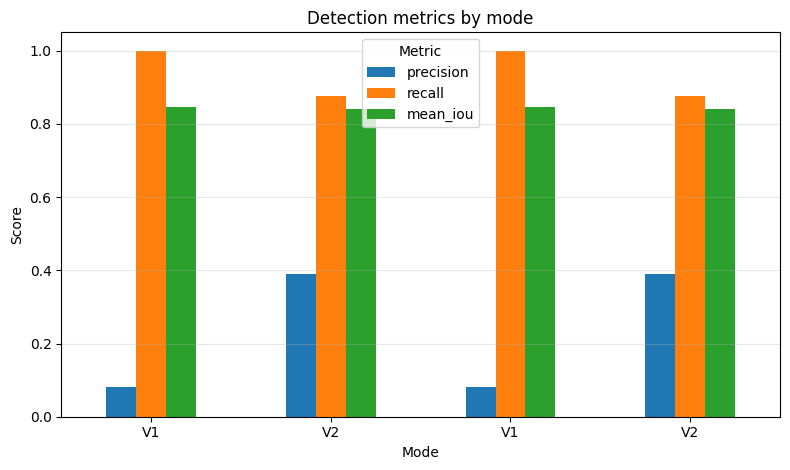

Saved: artifacts\figures\detection_metrics.png


In [51]:
from pathlib import Path

metrics_df = pd.DataFrame(results_summary)[["mode", "precision", "recall", "mean_iou"]].set_index("mode")

plt.figure(figsize=(8, 4.8))
ax = metrics_df.plot(kind="bar", figsize=(8, 4.8), ylim=(0, 1.05), rot=0)
ax.set_title("Detection metrics by mode")
ax.set_xlabel("Mode")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")
plt.tight_layout()

out_path = Path("artifacts/figures/detection_metrics.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")